In [6]:
import pandas as pd
import numpy as np
import json
import os
import torch

In [7]:
def count_parameters(path: str):
    model: dict = torch.load(path, map_location='cpu', weights_only=True)
    num_params = 0
    num_params_non_zero = 0
    for k, v in model.items():
        num_params += v.numel()
        num_params_non_zero += (v != 0).sum().item()
    return int(num_params_non_zero)
def count_parameters_all(path: str):
    return count_parameters(os.path.join(path, "model.pth")) + count_parameters(os.path.join(path, "relation_classifier.pth"))

In [8]:
models = [
    #"/local/scratch/clmn1/videoNCA/CataractsDataset/usual-dew-84",
    #"/local/scratch/clmn1/videoNCA/CataractsDataset/quiet-sound-104",
    #"/local/scratch/clmn1/videoNCA/CataractsDataset/ecstatic-valentine-92",
    #"/local/scratch/clmn1/videoNCA/CataractsDataset/decadent-romance-94",
    "/local/scratch/clmn1/videoNCA/CataractsDataset/confused-flower-107",

    "/local/scratch/clmn1/videoNCA/CataractsDataset/stilted-cherry-28", # UNet, motif
    "/local/scratch/clmn1/videoNCA/CataractsDataset/worthy-sun-109", # tinyUNet
    "/local/scratch/clmn1/videoNCA/CataractsDataset/pleasant-hill-85",
    "/local/scratch/clmn1/videoNCA/CataractsDataset/sunny-fire-86",
]

df = []
for model in models:
    eval_file = os.path.join(model, "scene_graph_evaluation_val.json")
    sg_results = json.load(open(eval_file, "r"))
    config = json.load(open(os.path.join(model, "config.json"), "r"))
    K = sg_results["K"]

    df.append({
        "name": f"{config['model']}+{config['relation_config']['method']}",
        "model": config["model"],
        "method": config["relation_config"]["method"],
        f"Recall@{K}": sg_results["Recall@K"],
        f"mRecall@{K}": sg_results["mRecall@K"],
        f"mAP@{K}": sg_results["mAP@K"],
        "num_params_rel": count_parameters(os.path.join(model, "relation_classifier.pth")),
        "num_params_seg": count_parameters(os.path.join(model, "model.pth")),
        "num_params_all": count_parameters_all(model),
    })

df = pd.DataFrame(df)
df

,name,model,method,Recall@6,mRecall@6,mAP@6,num_params_rel,num_params_seg,num_params_all
0,LargeOctreeNCA2D+direct_prediction,LargeOctreeNCA2D,direct_prediction,0.630840,0.502555,0.152527,144679,53985,198664
1,SurgicalUNet+motif,SurgicalUNet,motif,0.659238,0.493179,0.178674,4489735,68332580,72822315
2,TinySurgicalUNet+motif,TinySurgicalUNet,motif,0.546629,0.463188,0.172510,274567,268100,542667
3,SurgicalSegFormer+motif,SurgicalSegFormer,motif,0.667495,0.516163,0.208997,6324743,3719283,10044026
4,SurgicalSwinUNet+motif,SurgicalSwinUNet,motif,0.656021,0.541242,0.270418,4620807,27941700,32562507


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",
    palette="deep"
)
x_col = "num_params_all"

metrics = {
    f"Recall@{K}": {"label": "Recall@K", "marker": "o"},
    f"mRecall@{K}": {"label": "mRecall@K", "marker": "s"},
    f"mAP@{K}": {"label": "mAP@K", "marker": "D"},
}


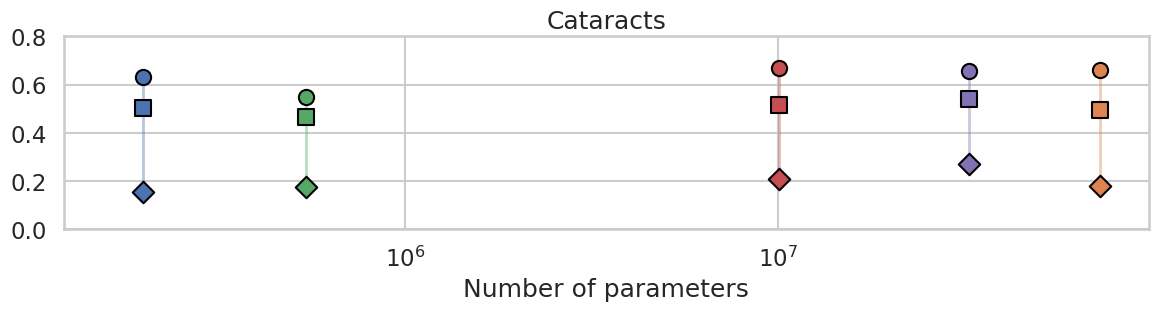

In [10]:
methods = df["model"].unique()
palette = dict(zip(methods, sns.color_palette(n_colors=len(methods))))

plt.figure(figsize=(14, 2.5))

for _, row in df.iterrows():
    x = row[x_col]
    color = palette[row["model"]]

    plt.vlines(
        x=x,
        ymin=min(row[m] for m in metrics),
        ymax=max(row[m] for m in metrics),
        color=color,
        alpha=0.4,
        linewidth=2
    )

    for m, cfg in metrics.items():
        plt.scatter(
            x,
            row[m],
            marker=cfg["marker"],
            s=120,
            color=color,
            edgecolor="black",
            zorder=3
        )
from matplotlib.lines import Line2D
metric_handles = [
    Line2D(
        [0], [0],
        marker=cfg["marker"],
        color="black",
        linestyle="None",
        markersize=10,
        label=cfg["label"]
    )
    for cfg in metrics.values()
]
model_handles = [
    Line2D(
        [0], [0],
        color=palette[model],
        lw=3,
        label=model
    )
    for model in methods
]
ax = plt.gca()

if False:
    legend_metrics = ax.legend(
        handles=metric_handles,
        title="Metric",
        loc="lower left",
        frameon=True
    )

    ax.add_artist(legend_metrics)  # keep first legend

    ax.legend(
        handles=model_handles,
        title="Model",
        loc="lower right",
        frameon=True
    )
plt.title("Cataracts")
plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylim(0, 0.8)
#plt.ylabel("Metric value")
#plt.title(f"Recall / mRecall / mAP vs Model Size (K={K})")
plt.xlim(121967.53410034659, 98731706.95666127)
plt.savefig("plots/cataracts_relation.pdf", bbox_inches="tight")